# PricePoint — 10 · Error analysis

**Why:** one score such as "MAE = 21,000 BDT" hides *where* the mistakes are. Here we look at the best model's errors on the hidden test laptops: which laptops it gets wrong, whether it is worse for cheap or expensive ones, and how often it is close.

**Model used:** Gradient Boosting with the same settings as notebook 07 and `src/train_and_export.py`, i.e. the model the website actually uses.

In [1]:
import json

import numpy as np
import pandas as pd
try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None
    print("matplotlib is not installed, so charts will be skipped. To see them: pip install matplotlib")

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor

In [2]:

ML_FOLDER = None

candidates = [Path(".."), Path("."), Path("ml")]
if ML_FOLDER is not None:
    candidates.insert(0, Path(ML_FOLDER))

for base in candidates:
    if (base / "data" / "laptop_price_clean.csv").exists():
        DATA_DIR = base / "data"
        MODEL_DIR = base / "models"
        break
else:
    raise FileNotFoundError(
        "Cannot find data/laptop_price_clean.csv. Move this notebook into PricePoint/ml/notebooks, "
        "or set ML_FOLDER in this cell to the path of your project's ml folder."
    )

MODEL_DIR.mkdir(exist_ok=True)

In [3]:

clean = pd.read_csv(DATA_DIR / "laptop_price_clean.csv")

clean["touchscreen"] = clean["touchscreen"].astype(int)
clean["ips"] = clean["ips"].astype(int)

# the columns the models will use
categorical_columns = ["brand", "type", "cpu_brand", "storage_type", "gpu_brand", "os"]
numeric_columns = [
    "inches",
    "touchscreen",
    "ips",
    "resolution_pixels",
    "cpu_speed_ghz",
    "ram_gb",
    "storage_gb",
    "weight_kg",
]

X = clean[categorical_columns + numeric_columns]
y = clean["price_bdt"]

print("rows:", len(X))
print("features:", X.shape[1])

rows: 1303
features: 14


## Split into training and testing

In [4]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("training rows:", len(X_train))
print("testing rows :", len(X_test))

training rows: 1042
testing rows : 261


## Build and train the model

In [5]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "category",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_columns,
        ),
        ("number", "passthrough", numeric_columns),
    ]
)

In [6]:

settings = {"n_estimators": 120, "learning_rate": 0.08, "max_depth": 4, "subsample": 0.85}

pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42, **settings)),
])
pipeline.fit(X_train, y_train)
print("model trained")

model trained


## Predicted vs actual price

Each dot is one test laptop. A perfect model would put every dot on the red line.

test MAE: 21398 BDT
test R² : 0.822


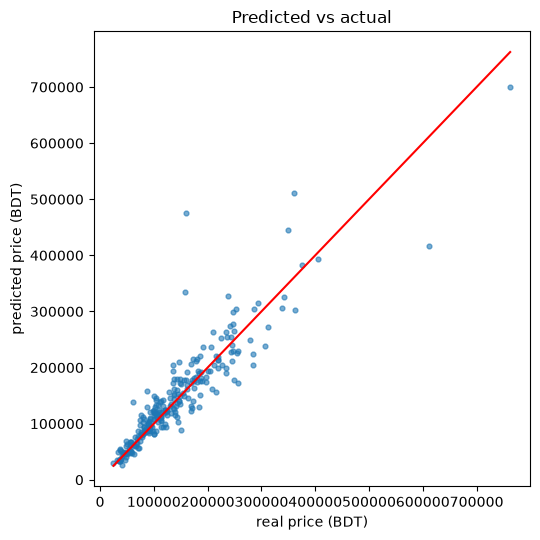

In [7]:

y_pred = pipeline.predict(X_test)

print("test MAE:", round(mean_absolute_error(y_test, y_pred)), "BDT")
print("test R² :", round(r2_score(y_test, y_pred), 3))

if plt is not None:
    plt.figure(figsize=(5.5, 5.5))
    plt.scatter(y_test, y_pred, s=12, alpha=0.6)
    limit = [y_test.min(), y_test.max()]
    plt.plot(limit, limit, color="red")
    plt.xlabel("real price (BDT)")
    plt.ylabel("predicted price (BDT)")
    plt.title("Predicted vs actual")
    plt.tight_layout()
    plt.show()

## A table of every mistake

`error` = predicted − real. A positive error means the model guessed too high.

In [8]:

errors = X_test[["brand", "type", "cpu_brand", "ram_gb", "storage_gb", "storage_type"]].copy()
errors["real"] = y_test
errors["predicted"] = y_pred.round()
errors["error"] = errors["predicted"] - errors["real"]
errors["abs_error"] = errors["error"].abs()
errors["pct_error"] = errors["abs_error"] / errors["real"] * 100

biggest = errors.sort_values("abs_error", ascending=False).head(10)[
    ["brand", "type", "cpu_brand", "ram_gb", "storage_gb", "real", "predicted", "error"]
]

print("the 10 biggest mistakes:")
print(biggest.to_string(index=False))

the 10 biggest mistakes:
 brand               type   cpu_brand  ram_gb  storage_gb   real  predicted     error
  Asus             Gaming    Intel i7      32         512 159875   475866.0  315991.0
Lenovo           Notebook Intel Other      32        1024 612375   417476.0 -194899.0
  Asus             Gaming    Intel i7      24        1280 158625   335037.0  176412.0
  Dell        Workstation    Intel i7      16         256 360608   510771.0  150163.0
  Asus             Gaming    Intel i7      32         512 349875   444795.0   94920.0
Lenovo 2 in 1 Convertible    Intel i7      16         512 237375   326876.0   89501.0
  Dell             Gaming    Intel i5      16        1152 256375   172930.0  -83445.0
    HP 2 in 1 Convertible    Intel i5       8         256 284625   204266.0  -80359.0
    HP 2 in 1 Convertible Intel Other       8          64  61875   138321.0   76446.0
    HP             Gaming    Intel i7      12        1280 249875   177456.0  -72419.0


## How often is it close?

An easy way to describe accuracy: *"for X% of laptops the prediction is within 10% / 20% of the real price."*

In [9]:

for limit_pct in (10, 20, 30):
    share = (errors["pct_error"] <= limit_pct).mean()
    print(f"within {limit_pct}% of the real price: {share:.0%} of laptops")

print()
print("average error          :", round(errors["abs_error"].mean()), "BDT")
print("median error           :", round(errors["abs_error"].median()), "BDT")
print("average error in %     :", round(errors["pct_error"].mean(), 1), "%")
print("median error in %      :", round(errors["pct_error"].median(), 1), "%")

within 10% of the real price: 46% of laptops
within 20% of the real price: 74% of laptops
within 30% of the real price: 90% of laptops

average error          : 21398 BDT
median error           : 12788 BDT
average error in %     : 15.7 %
median error in %      : 11.7 %


## Cheap vs expensive laptops

We cut the test laptops into 4 equal groups by real price and measure the error in each group, in taka and in percent.

             laptops  average_price  average_error  average_error_pct
price_group                                                          
Budget            66        55443.2         9182.3               16.6
Mid-range         65        97933.6        14891.4               15.3
Upper-mid         65       145276.7        26700.1               17.9
Premium           65       255164.7        35006.8               13.2


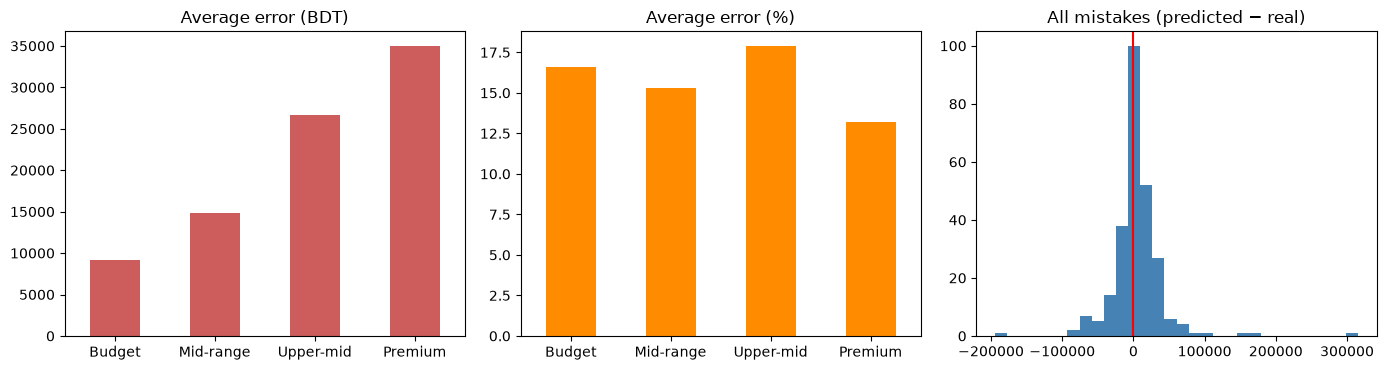

In [10]:

errors["price_group"] = pd.qcut(
    errors["real"], 4, labels=["Budget", "Mid-range", "Upper-mid", "Premium"]
)

by_group = errors.groupby("price_group", observed=True).agg(
    laptops=("real", "size"),
    average_price=("real", "mean"),
    average_error=("abs_error", "mean"),
    average_error_pct=("pct_error", "mean"),
).round(1)
print(by_group.to_string())

if plt is not None:
    fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
    by_group["average_error"].plot.bar(ax=axes[0], color="indianred", title="Average error (BDT)")
    by_group["average_error_pct"].plot.bar(ax=axes[1], color="darkorange", title="Average error (%)")
    axes[2].hist(errors["error"], bins=30, color="steelblue")
    axes[2].axvline(0, color="red")
    axes[2].set_title("All mistakes (predicted − real)")
    for ax in axes[:2]:
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=0)
    plt.tight_layout()
    plt.show()